In [ ]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'mnist' in file.lower() or 'MNIST' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/AI and Machine Learning/mnist_train.csv
/content/drive/MyDrive/AI and Machine Learning/mnist_dataset.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Set the path to your MNIST CSV file
csv_file = '/content/drive/MyDrive/AI and Machine Learning/mnist_train.csv'

print("All libraries imported successfully!")
print(f" Using file: {csv_file}")

All libraries imported successfully!
 Using file: /content/drive/MyDrive/AI and Machine Learning/mnist_train.csv


In [ ]:
# STEP 1 - Softmax Function

# The softmax function converts raw scores (logits) into
# a probability distribution over K classes.
# Each output value lies between 0 and 1, and all outputs sum to 1.
# Numerical stabilization is applied by subtracting the row maximum
# to prevent overflow when computing large exponentials.

def softmax(z):
    """
    Computes the softmax probabilities for a given input matrix.

    Parameters:
        z (numpy.ndarray): Logits of shape (m, n), where
                           m is the number of samples and
                           n is the number of classes.

    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n),
                       where each row sums to 1.
    """
    # Subtract max value per row for numerical stability
    z_stable = z - np.max(z, axis=1, keepdims=True)

    # Compute exponentials
    exp_z = np.exp(z_stable)

    # Divide each element by the sum of its row
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# Test Case - Softmax Function
# Verifies that each row of the output sums to 1,
# which is the fundamental property of a probability distribution.

z_test = np.array([[2.0, 1.0, 0.1],
                   [1.0, 1.0, 1.0]])

softmax_output = softmax(z_test)

# Verify rows sum to 1
row_sums = np.sum(softmax_output, axis=1)

assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("Softmax output:")
print(softmax_output)
print("Row sums:", row_sums)
print("Softmax function passed the test case.")

Softmax output:
[[0.65900114 0.24243297 0.09856589]
 [0.33333333 0.33333333 0.33333333]]
Row sums: [1. 1.]
Softmax function passed the test case.


In [ ]:
# STEP 2 - Prediction Function

# The prediction function computes the class label for each sample
# by first calculating the logits (z = XW + b), applying softmax
# to obtain class probabilities, and then selecting the class
# with the highest probability using argmax.

def predict_softmax(X, W, b):
    """
    Predicts the class labels for a set of samples using
    the trained softmax regression model.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d),
                           where n is the number of samples
                           and d is the number of features.
        W (numpy.ndarray): Weight matrix of shape (d, c),
                           where c is the number of classes.
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        numpy.ndarray: Predicted class labels of shape (n,),
                       where each value is the index of the
                       predicted class.
    """
    # Compute logits: raw scores for each class
    z = np.dot(X, W) + b

    # Apply softmax to get probability distribution
    probabilities = softmax(z)

    # Select class with highest probability for each sample
    predicted_classes = np.argmax(probabilities, axis=1)

    return predicted_classes

# Test Case - Prediction Function
# Verifies that the output shape matches the number
# of input samples, confirming valid output dimensions.

X_test = np.array([[0.2, 0.8],
                   [0.5, 0.5],
                   [0.9, 0.1]])   # Feature matrix (3 samples, 2 features)

W_test = np.array([[0.4, 0.2, 0.1],
                   [0.3, 0.7, 0.5]])  # Weight matrix (2 features, 3 classes)

b_test = np.array([0.1, 0.2, 0.3])   # Bias vector (3 classes)

y_pred_test = predict_softmax(X_test, W_test, b_test)

assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"

print("Predicted class labels:", y_pred_test)
print("Prediction function passed the test case.")

Predicted class labels: [1 1 0]
Prediction function passed the test case.


In [ ]:
# STEP 3 - Loss Function

# The categorical cross-entropy loss measures the difference
# between the predicted probability distribution and the true
# label distribution for a given set of samples.
# A lower loss indicates that the predicted probabilities
# are closer to the true labels.

def loss_softmax(y_pred, y):
    """
    Computes the categorical cross-entropy loss over a set of samples.

    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities of shape (n, c),
                                where n is the number of samples and
                                c is the number of classes.
        y (numpy.ndarray):      True labels (one-hot encoded) of shape (n, c).

    Returns:
        float: Average cross-entropy loss over all samples.
    """
    # Number of samples
    n = y.shape[0]

    # Clip predictions to avoid log(0) which would cause infinity
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)

    # Compute cross-entropy loss
    # Multiply true labels by log of predicted probabilities
    # Sum over classes, then average over all samples
    loss = -np.sum(y * np.log(y_pred_clipped)) / n

    return loss

# Test Case - Loss Function
# Verifies that correct predictions produce a lower loss
# than incorrect predictions, confirming the function
# penalizes wrong predictions appropriately.

# True one-hot labels
y_true_correct = np.array([[1, 0, 0],
                            [0, 1, 0],
                            [0, 0, 1]])

# High confidence correct predictions - expected low loss
y_pred_correct = np.array([[0.9,  0.05, 0.05],
                            [0.1,  0.85, 0.05],
                            [0.05, 0.1,  0.85]])

# High confidence incorrect predictions - expected high loss
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                              [0.1,  0.05, 0.85],
                              [0.85, 0.1,  0.05]])

# Compute loss for both cases
loss_correct   = loss_softmax(y_pred_correct,   y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, \
    f"Test failed: Expected loss_correct < loss_incorrect, \
    but got {loss_correct:.4f} >= {loss_incorrect:.4f}"

print(f"Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")
print("Loss function passed the test case.")

Cross-Entropy Loss (Correct Predictions):   0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957
Loss function passed the test case.


In [ ]:

# STEP 4 - Cost Function

# The cost function computes the average cross-entropy loss
# over all samples in the dataset. It combines the softmax
# and loss functions to evaluate the overall model performance
# given the current weights and biases.

def cost_softmax(X, y, W, b):
    """
    Computes the average softmax regression cost over all samples.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d),
                           where n is the number of samples
                           and d is the number of features.
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c),
                           where c is the number of classes.
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        float: Average cross-entropy loss over all samples.
    """
    # Number of samples
    n = X.shape[0]

    # Compute logits
    z = np.dot(X, W) + b

    # Compute softmax probabilities
    y_pred = softmax(z)

    # Compute and return average cross-entropy loss
    total_loss = loss_softmax(y_pred, y)

    return total_loss


# -----------------------------------------------
# Test Case - Cost Function
# Verifies that the cost for incorrect predictions is
# higher than for correct predictions, confirming that
# the cost function behaves as expected.

# Example 1 - Correct predictions (low cost expected)
X_correct   = np.array([[1.0, 0.0],
                         [0.0, 1.0]])
y_correct   = np.array([[1, 0],
                         [0, 1]])
W_correct   = np.array([[5.0, -2.0],
                         [-3.0, 5.0]])
b_correct   = np.array([0.1, 0.1])

# Example 2 - Incorrect predictions (high cost expected)
X_incorrect = np.array([[0.1, 0.9],
                         [0.8, 0.2]])
y_incorrect = np.array([[1, 0],
                         [0, 1]])
W_incorrect = np.array([[0.1, 2.0],
                         [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

# Compute cost for both cases
cost_correct   = cost_softmax(X_correct,   y_correct,   W_correct,   b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, \
    f"Test failed: Incorrect cost {cost_incorrect} is not \
    greater than correct cost {cost_correct}"

print(f"Cost for correct predictions:   {cost_correct:.4f}")
print(f"Cost for incorrect predictions: {cost_incorrect:.4f}")
print("Cost function passed the test case.")

Cost for correct predictions:   0.0006
Cost for incorrect predictions: 0.2993
Cost function passed the test case.


In [ ]:
# STEP 5 - Compute Gradients and Gradient Descent

# The gradient computation determines the direction and magnitude
# of parameter updates required to minimize the cost function.
# The gradients are derived from the difference between the
# predicted probabilities and the true labels.

def compute_gradient_softmax(X, y, W, b):
    """
    Computes the gradients of the cost function with respect
    to the weights and biases.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        tuple: Gradients with respect to weights (d, c)
               and biases (c,).
    """
    # Number of samples
    n = X.shape[0]

    # Compute softmax probabilities
    z     = np.dot(X, W) + b
    y_pred = softmax(z)

    # Compute difference between predicted and true labels
    diff = y_pred - y

    # Gradient with respect to weights
    # Each weight gradient is the average of the outer product
    # of input features and prediction errors
    grad_W = np.dot(X.T, diff) / n

    # Gradient with respect to biases
    # Average prediction error across all samples
    grad_b = np.sum(diff, axis=0) / n

    return grad_W, grad_b

# Test Case - Compute Gradient Softmax
# Verifies that the computed gradients match the
# manually calculated gradients within numerical tolerance.

X_test = np.array([[0.2, 0.8],
                   [0.5, 0.5],
                   [0.9, 0.1]])
y_test = np.array([[1, 0, 0],
                   [0, 1, 0],
                   [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1],
                   [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

# Manually compute gradients for verification
z_test        = np.dot(X_test, W_test) + b_test
y_pred_test   = softmax(z_test)
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual), \
    f"Test failed: Gradients w.r.t. W do not match.\
    \nExpected: {grad_W_manual}\nGot: {grad_W}"

assert np.allclose(grad_b, grad_b_manual), \
    f"Test failed: Gradients w.r.t. b do not match.\
    \nExpected: {grad_b_manual}\nGot: {grad_b}"

print("Gradient w.r.t. W:\n", grad_W)
print("Gradient w.r.t. b:\n", grad_b)
print("Gradient computation passed the test case.")


# Gradient Descent Algorithm


# The gradient descent algorithm iteratively updates the weights
# and biases in the direction of the negative gradient to minimize
# the cost function. The learning rate controls the step size
# of each update, and the process continues for a fixed number
# of iterations.

def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Performs gradient descent to optimize the weights and biases
    of the softmax regression model.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).
        alpha (float):     Learning rate controlling the step size.
        n_iter (int):      Number of iterations to run gradient descent.
        show_cost (bool):  Whether to print cost at regular intervals.

    Returns:
        tuple: Optimized weights, optimized biases, and cost history.
    """
    # List to store cost at each iteration for plotting
    cost_history = []

    for i in range(n_iter):

        # Compute gradients at current parameter values
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update weights and biases in negative gradient direction
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Compute and store current cost
        current_cost = cost_softmax(X, y, W, b)
        cost_history.append(current_cost)

        # Print cost every 100 iterations if show_cost is enabled
        if show_cost and i % 100 == 0:
            print(f"Iteration {i:4d} - Cost: {current_cost:.4f}")

    return W, b, cost_history

Gradient w.r.t. W:
 [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b:
 [-0.03290036  0.02484708  0.00805328]
Gradient computation passed the test case.


Loading dataset, this may take a moment...
Dataset loaded. Shape: (42000, 785)
Training set size:  (33600, 784)
Test set size:      (8400, 784)


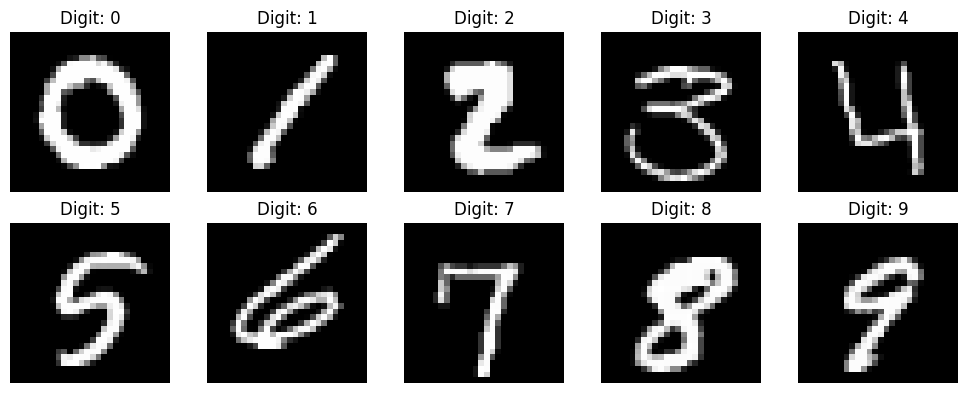

Dimension check passed. X_train and y_train lengths match.


In [ ]:
# STEP 6 - Load and Prepare MNIST Dataset

# The load_and_prepare_mnist function reads the MNIST CSV file,
# separates the labels from the pixel values, normalizes the
# pixel values to the range [0, 1], and splits the dataset
# into training and test sets.
# The plot_sample_images function visualizes one representative
# image per digit class to confirm the data has been loaded correctly.

def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).

    Parameters:
        X (numpy.ndarray): Feature matrix containing pixel values.
        y (numpy.ndarray): Labels corresponding to each image.
    """
    plt.figure(figsize=(10, 4))

    # Get all unique digit classes
    unique_classes = np.unique(y)

    for i, digit in enumerate(unique_classes):
        # Find the first occurrence of each digit class
        index = np.where(y == digit)[0][0]

        # Reshape the 1D pixel array back to 28x28 image
        image = X[index].reshape(28, 28)

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into training and test
    sets, normalizes pixel values, and plots one image per class.

    Parameters:
        csv_file (str):      Path to the MNIST CSV file.
        test_size (float):   Proportion of data for testing (default: 0.2).
        random_state (int):  Random seed for reproducibility (default: 42).

    Returns:
        tuple: X_train, X_test, y_train, y_test arrays.
    """
    # Load the dataset into a pandas DataFrame
    print("Loading dataset, this may take a moment...")
    df = pd.read_csv(csv_file)
    print(f"Dataset loaded. Shape: {df.shape}")

    # First column contains the labels (digit 0-9)
    y = df.iloc[:, 0].values

    # Remaining columns contain the pixel values (784 pixels per image)
    X = df.iloc[:, 1:].values

    # Normalize pixel values from range [0, 255] to [0, 1]
    # This helps the gradient descent converge faster
    X = X / 255.0

    # Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state
    )

    print(f"Training set size:  {X_train.shape}")
    print(f"Test set size:      {X_test.shape}")

    # Plot one sample image per digit class
    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test


# Load the MNIST dataset using the function above

X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file)

# Verify dimensions match between features and labels
assert len(X_train) == len(y_train), \
    f"Error: X_train and y_train lengths do not match. \
    X={len(X_train)}, y={len(y_train)}"

print("Dimension check passed. X_train and y_train lengths match.")

# Question 1 - Written Answer
# Is extracting pixel values sufficient for effective feature extraction?
# Include your answer as a comment below:

# Answer: Extracting raw pixel values alone is not always sufficient
# for effective feature extraction. While pixel values capture the
# basic intensity information of an image, they do not capture
# higher-level features such as edges, shapes, or textures that
# are more meaningful for classification tasks. Additionally,
# raw pixel values are sensitive to variations in lighting,
# rotation, and scale, which can negatively affect model performance.
# More advanced feature extraction techniques such as convolutional
# neural networks (CNNs) or histogram of oriented gradients (HOG)
# are typically more effective for image classification tasks.

y_train shape after one-hot encoding: (33600, 10)
y_test shape after one-hot encoding:  (8400, 10)

Number of features (d): 784
Number of classes  (c): 10

Weight matrix shape: (784, 10)
Bias vector shape:   (10,)

Learning rate:      0.1
Number of iterations: 1000

Training started...
Iteration    0 - Cost: 2.1868
Iteration  100 - Cost: 0.6000
Iteration  200 - Cost: 0.4816
Iteration  300 - Cost: 0.4324
Iteration  400 - Cost: 0.4039
Iteration  500 - Cost: 0.3847
Iteration  600 - Cost: 0.3707
Iteration  700 - Cost: 0.3598
Iteration  800 - Cost: 0.3510
Iteration  900 - Cost: 0.3437

Training complete.


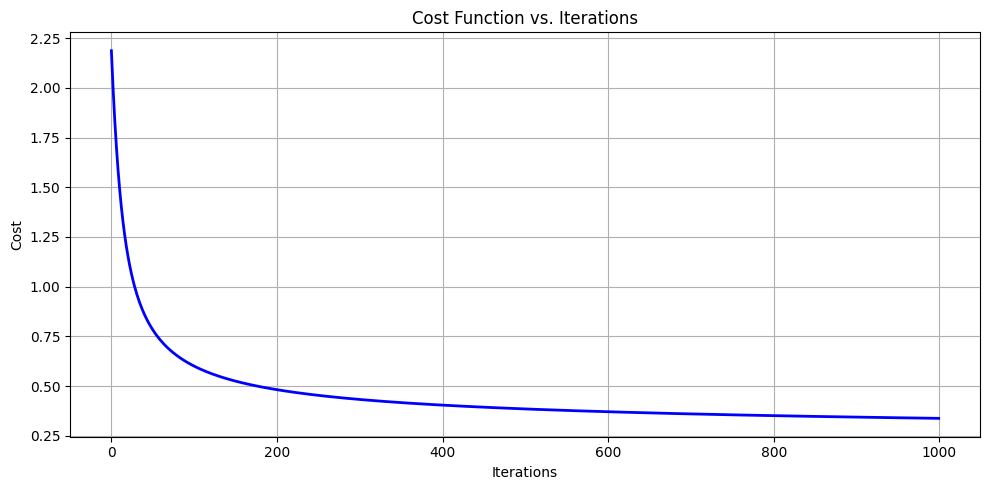

In [29]:
# STEP 7 - Training the Softmax Regression Model

# The training process involves one-hot encoding the labels,
# initializing the weight matrix and bias vector, and running
# gradient descent to iteratively optimize the parameters.
# The cost history is plotted to visualize model convergence.

# One-hot encode the labels if not already encoded
# One-hot encoding converts integer labels into binary vectors
# e.g. label 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test  = encoder.transform(y_test.reshape(-1, 1))

print(f"y_train shape after one-hot encoding: {y_train.shape}")
print(f"y_test shape after one-hot encoding:  {y_test.shape}")


# Extract dimensions from the dataset
d = X_train.shape[1]   # Number of features (784 pixels per image)
c = y_train.shape[1]   # Number of classes (10 digits: 0-9)

print(f"\nNumber of features (d): {d}")
print(f"Number of classes  (c): {c}")

# Initialize weights with small random values
# and biases with zeros
# Small random weights break symmetry and allow
# the model to learn different features per class
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

print(f"\nWeight matrix shape: {W.shape}")
print(f"Bias vector shape:   {b.shape}")


# Set hyperparameters for gradient descent
alpha  = 0.1    # Learning rate - controls step size per iteration
n_iter = 1000   # Number of iterations to run gradient descent

print(f"\nLearning rate:      {alpha}")
print(f"Number of iterations: {n_iter}")
print("\nTraining started...")

# Train the model using gradient descent
# This may take a few minutes due to the size of the dataset
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train,
    W, b,
    alpha, n_iter,
    show_cost=True
)

print("\nTraining complete.")

# Plot cost history to visualize convergence
# The cost should decrease steadily over iterations
plt.figure(figsize=(10, 5))
plt.plot(cost_history, color='blue', linewidth=2)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.tight_layout()
plt.show()

Confusion Matrix:
[[779   0   1   1   3  11   9   0  11   1]
 [  1 889   2   1   1   1   2   2   9   1]
 [  6  10 735  14  26   2  11  16  25   1]
 [  2   5  27 801   1  39   6  11  27  18]
 [  1   1   7   2 773   4  11   2   2  36]
 [ 10   6   5  25  15 587  24   4  18   8]
 [  6   1   7   3   6   9 742   1   9   1]
 [  1  12  17   3  14   4   0 802   2  38]
 [  2  11   9  26   7  25   8   7 728  12]
 [  6   3   6  15  23   7   0  30   7 741]]

Precision: 0.90
Recall:    0.90
F1-Score:  0.90


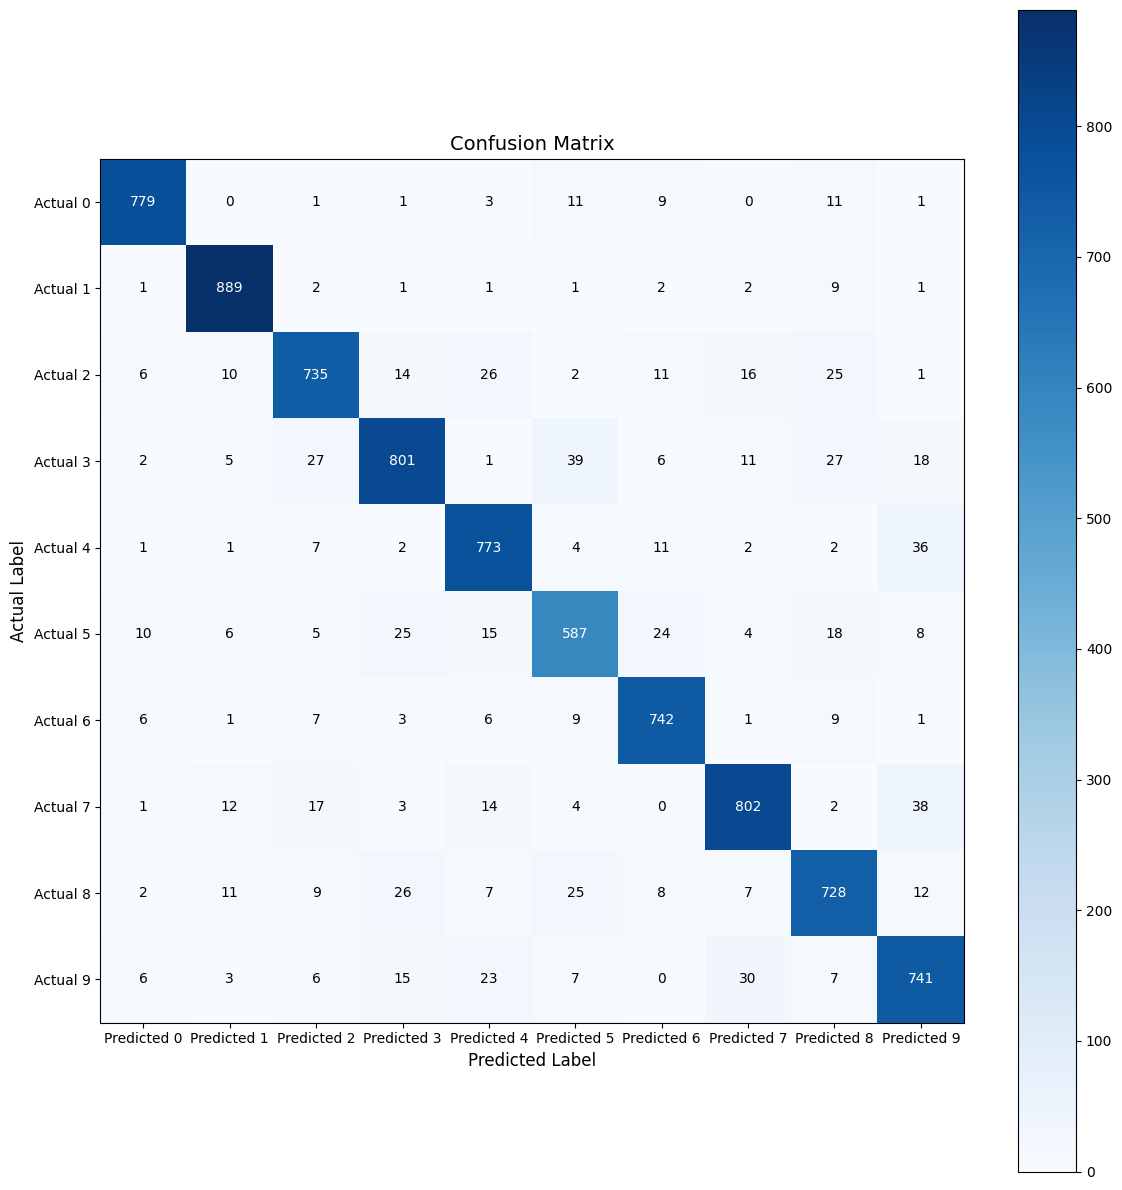

In [30]:
# STEP 8 - Evaluating the Model Performance

# The evaluation step measures how well the trained model
# performs on unseen test data. The confusion matrix shows
# the distribution of correct and incorrect predictions
# across all digit classes. Precision, recall and F1-score
# provide a quantitative summary of model performance.

def evaluate_classification(y_true, y_pred):
    """
    Evaluates classification performance using confusion matrix,
    precision, recall and F1-score.

    Parameters:
        y_true (numpy.ndarray): True class labels.
        y_pred (numpy.ndarray): Predicted class labels.

    Returns:
        tuple: Confusion matrix, precision, recall, F1-score.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute precision, recall and F1-score
    # weighted average accounts for class imbalance
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred,    average='weighted')
    f1        = f1_score(y_true, y_pred,         average='weighted')

    return cm, precision, recall, f1


# Generate predictions on the test set
# using the optimized weights and biases
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# Convert one-hot encoded test labels back to integer form
y_test_labels = np.argmax(y_test, axis=1)

# Evaluate the model performance
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print evaluation metrics
print("Confusion Matrix:")
print(cm)
print(f"\nPrecision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

# -----------------------------------------------

# Visualize the confusion matrix as a heatmap
# Each row represents the actual digit class
# Each column represents the predicted digit class
# The diagonal entries show correct predictions
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')

# Set axis tick labels dynamically based on number of classes
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}'    for i in range(num_classes)])

# Annotate each cell with its count value
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm) / 2 else 'black')

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label',    fontsize=12)
plt.colorbar(cax)
plt.tight_layout()
plt.show()

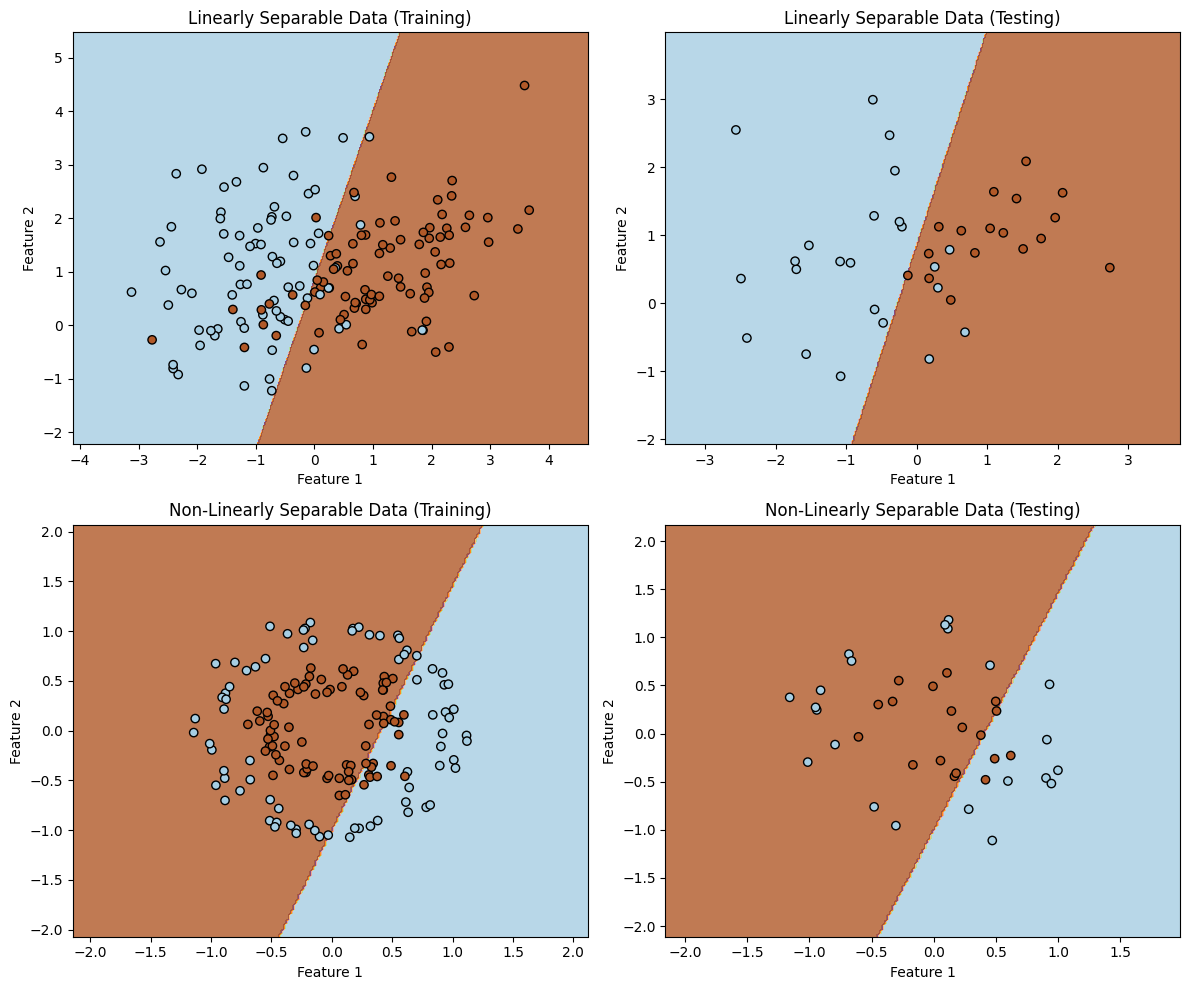

In [31]:
# STEP 9 - Linear Separability and Logistic Regression

# This section demonstrates the difference between linearly
# separable and non-linearly separable datasets by training
# a logistic regression model on both and visualizing the
# resulting decision boundaries.
# A linearly separable dataset can be perfectly divided by
# a straight line, whereas a non-linearly separable dataset
# requires a more complex boundary.

from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# Generate a linearly separable dataset
# make_classification produces a dataset that can be
# separated by a linear decision boundary
X_linear, y_linear = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Split linearly separable data into training and test sets
X_train_linear, X_test_linear, \
y_train_linear, y_test_linear = train_test_split(
    X_linear, y_linear,
    test_size=0.2,
    random_state=42
)

# Train logistic regression on linearly separable data
logistic_linear = LogisticRegression()
logistic_linear.fit(X_train_linear, y_train_linear)


# Generate a non-linearly separable dataset
# make_circles produces two concentric circles that
# cannot be separated by a straight line
X_nonlinear, y_nonlinear = make_circles(
    n_samples=200,
    noise=0.1,
    factor=0.5,
    random_state=42
)

# Split non-linearly separable data into training and test sets
X_train_nonlinear, X_test_nonlinear, \
y_train_nonlinear, y_test_nonlinear = train_test_split(
    X_nonlinear, y_nonlinear,
    test_size=0.2,
    random_state=42
)

# Train logistic regression on non-linearly separable data
logistic_nonlinear = LogisticRegression()
logistic_nonlinear.fit(X_train_nonlinear, y_train_nonlinear)


# The plot_decision_boundary function visualizes the decision
# boundary learned by the model by creating a dense mesh grid
# of points and predicting the class for each point.
# The resulting colored regions show which class the model
# assigns to each area of the feature space.

def plot_decision_boundary(ax, model, X, y, title):
    """
    Plots the decision boundary of a classification model.

    Parameters:
        ax (matplotlib.axes): Axes object to plot on.
        model: Trained classification model with predict method.
        X (numpy.ndarray): Feature matrix of shape (n, 2).
        y (numpy.ndarray): True class labels of shape (n,).
        title (str): Title for the plot.
    """
    # Step size for the mesh grid
    h = 0.02

    # Define grid boundaries with padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create mesh grid covering the feature space
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Predict class for every point in the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary regions
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)

    # Overlay the actual data points
    ax.scatter(X[:, 0], X[:, 1], c=y,
               edgecolors='k', cmap=plt.cm.Paired)

    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# Create a 2x2 grid of subplots showing decision boundaries
# for both datasets on training and test sets
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Linearly separable - training set
plot_decision_boundary(
    axes[0, 0], logistic_linear,
    X_train_linear, y_train_linear,
    'Linearly Separable Data (Training)'
)

# Linearly separable - test set
plot_decision_boundary(
    axes[0, 1], logistic_linear,
    X_test_linear, y_test_linear,
    'Linearly Separable Data (Testing)'
)

# Non-linearly separable - training set
plot_decision_boundary(
    axes[1, 0], logistic_nonlinear,
    X_train_nonlinear, y_train_nonlinear,
    'Non-Linearly Separable Data (Training)'
)

# Non-linearly separable - test set
plot_decision_boundary(
    axes[1, 1], logistic_nonlinear,
    X_test_nonlinear, y_test_nonlinear,
    'Non-Linearly Separable Data (Testing)'
)

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()